## Вариант_1

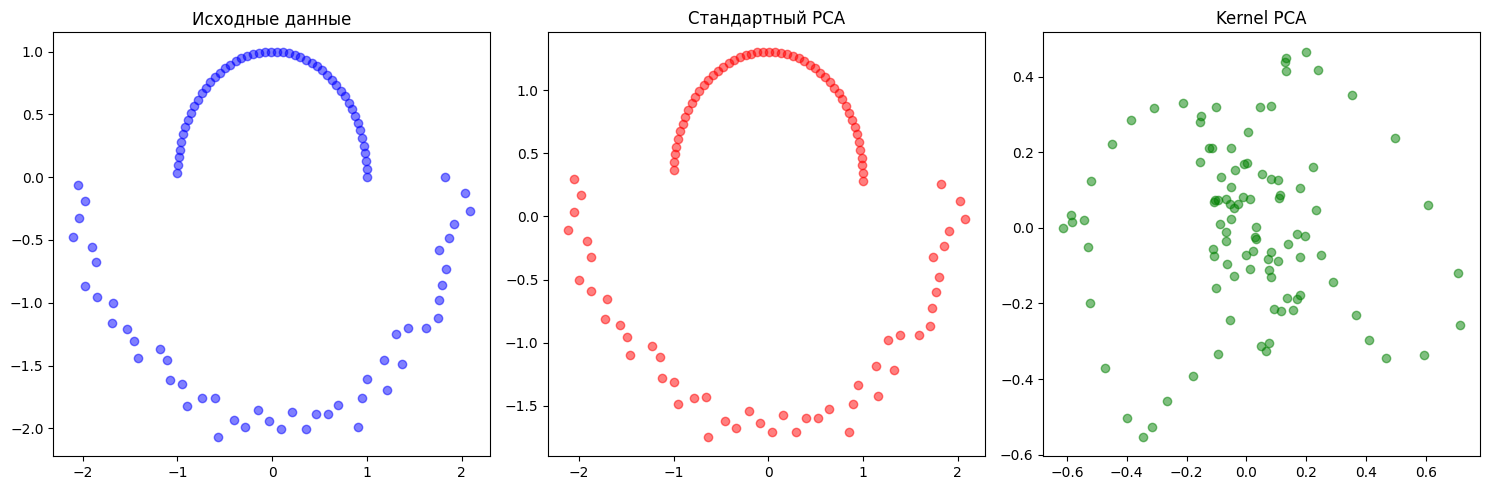

In [1]:
from sklearn.kernel_approximation import RBFSampler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

class CustomKernelPCA:
    def __init__(self, n_components, sigma=0.1):
        self.n_components = n_components
        self.sigma = sigma
        self.rbf_sampler = RBFSampler(gamma=1/(2*sigma**2), random_state=42)
        self.pca = PCA(n_components=n_components)

    def fit_transform(self, X):
        X_rbf = self.rbf_sampler.fit_transform(X)
        return self.pca.fit_transform(X_rbf)

    def inverse_transform(self, X):
        X_rbf = self.pca.inverse_transform(X)
        return self._approximate_inverse_rbf(X_rbf)

    def _approximate_inverse_rbf(self, X_rbf):
        dist_matrix = np.sum(X_rbf**2, axis=1).reshape(-1, 1) + \
                     np.sum(X_rbf**2, axis=1) - 2 * np.dot(X_rbf, X_rbf.T)
        return dist_matrix / (2 * self.sigma**2)

np.random.seed(42)
theta = np.linspace(0, 2*np.pi, 100)
r = np.concatenate([np.ones(50), 2 + 0.1*np.random.randn(50)])
x = r * np.cos(theta)
y = r * np.sin(theta)
X = np.column_stack((x, y))

kpca = CustomKernelPCA(n_components=2, sigma=0.1)
X_kpca = kpca.fit_transform(X)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.scatter(X[:, 0], X[:, 1], c='blue', alpha=0.5)
plt.title('Исходные данные')

plt.subplot(132)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='red', alpha=0.5)
plt.title('Стандартный PCA')

plt.subplot(133)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c='green', alpha=0.5)
plt.title('Kernel PCA')

plt.tight_layout()
plt.show()

## Вариант_2

In [ ]:
import numpy as np
from sklearn.kernel_approximation import RBFSampler, Nystroem
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel, polynomial_kernel, sigmoid_kernel
import matplotlib.pyplot as plt

class AdvancedKernelPCA:
    def __init__(self, n_components=None, kernel='rbf', sigma=0.1, degree=3,
                 gamma='scale', coef0=1, nystroem_samples=None):
        self.n_components = n_components
        self.kernel_type = kernel.lower()
        self.sigma = sigma
        self.degree = degree
        self.gamma = gamma
        self.coef0 = coef0
        self.nystroem_samples = nystroem_samples
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=n_components)

    def _get_kernel_matrix(self, X):
        if self.kernel_type == 'rbf':
            return rbf_kernel(X, gamma=self.gamma)
        elif self.kernel_type == 'poly':
            return polynomial_kernel(X, degree=self.degree, gamma=self.gamma,
                                   coef0=self.coef0)
        elif self.kernel_type == 'sigmoid':
            return sigmoid_kernel(X, gamma=self.gamma, coef0=self.coef0)
        else:
            raise ValueError(f"Неизвестный тип ядра: {self.kernel_type}")

    def _center_kernel_matrix(self, K):
        n_samples = K.shape[0]
        one_n = np.ones((n_samples, n_samples)) / n_samples
        return K - one_n.dot(K) - K.dot(one_n) + one_n.dot(K).dot(one_n)

    def fit_transform(self, X):
        X_scaled = self.scaler.fit_transform(X)
        K = self._get_kernel_matrix(X_scaled)
        K_centered = self._center_kernel_matrix(K)
        eigenvals, eigenvecs = np.linalg.eigh(K_centered)
        idx = eigenvals.argsort()[::-1]
        eigenvals = eigenvals[idx]
        eigenvecs = eigenvecs[:, idx]
        if self.n_components is None:
            self.n_components = X.shape[1]
        eigenvecs = eigenvecs[:, :self.n_components]

        eigenvecs = eigenvecs / np.sqrt(eigenvals[:self.n_components])

        return eigenvecs.T

    def inverse_transform(self, X_kpca):
        return self.scaler.inverse_transform(
            self.pca.inverse_transform(X_kpca)
        )

In [ ]:
t = np.linspace(0, 10*np.pi, 1000)
x = np.column_stack((
    np.cos(t) * np.exp(t/20),
    np.sin(t) * np.exp(t/20)
))

kpca_rbf = AdvancedKernelPCA(n_components=2, kernel='rbf', sigma=0.1)
kpca_poly = AdvancedKernelPCA(n_components=2, kernel='poly', degree=3)
kpca_sig = AdvancedKernelPCA(n_components=2, kernel='sigmoid')

X_kpca_rbf = kpca_rbf.fit_transform(x)
X_kpca_poly = kpca_poly.fit_transform(x)
X_kpca_sig = kpca_sig.fit_transform(x)

plt.figure(figsize=(15, 5))
plt.subplot(141)
plt.scatter(x[:, 0], x[:, 1], c=t, cmap='viridis')
plt.title('Исходные данные')

plt.subplot(142)
plt.scatter(X_kpca_rbf[:, 0], X_kpca_rbf[:, 1], c=t, cmap='viridis')
plt.title('Kernel PCA (RBF)')

plt.subplot(143)
plt.scatter(X_kpca_poly[:, 0], X_kpca_poly[:, 1], c=t, cmap='viridis')
plt.title('Kernel PCA (Polynomial)')

plt.subplot(144)
plt.scatter(X_kpca_sig[:, 0], X_kpca_sig[:, 1], c=t, cmap='viridis')
plt.title('Kernel PCA (Sigmoid)')

plt.tight_layout()
plt.show()